# Step by step Data Cleaning Impletation:
Cleaning Data before entering into RAG . so it makes more efficent and accurate without any misinformation.

### Step 1: Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df=pd.read_csv("../Data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Step 2: Basic statistics and missing Values

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [6]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
df["title"].duplicated().sum()

np.int64(0)

### Step 3: Filling Missing Values

In [9]:
missing_col_map={
    "director":"Unknown",
    "cast":"Unknown",
    "country":"Unknown",
    "date_added":"Unknown",
    "rating":"Unknown",
    "duration":"Unknown"
}
for column,value in missing_col_map.items():
    df[column]=df[column].fillna(value)
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [10]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Step 4: Checking Unique Values

In [13]:
print(df["type"].unique())
print(df["rating"].unique())
print(df["listed_in"].value_counts().head(20))

<ArrowStringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
<ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',  'Unknown', 'TV-Y7-FV',       'UR']
Length: 18, dtype: str
listed_in
Dramas, International Movies                         362
Documentaries                                        359
Stand-Up Comedy                                      334
Comedies, Dramas, International Movies               274
Dramas, Independent Movies, International Movies     252
Kids' TV                                             220
Children & Family Movies                             215
Children & Family Movies, Comedies                   201
Documentaries, International Movies                  186
Dramas, International Movies, Romantic Movies        180
Comedies, International Movies                       176
Comedies, International Movies, Romantic

In [14]:
df[df["rating"].str.contains("min", na=False)][
    ["title", "type", "rating", "duration", "release_year", "listed_in"]
]

,title,type,rating,duration,release_year,listed_in
5541,Louis C.K. 2017,Movie,74 min,Unknown,2017,Movies
5794,Louis C.K.: Hilarious,Movie,84 min,Unknown,2010,Movies
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,Unknown,2015,Movies


In [15]:
df["rating"].str.contains("min",na=False).shape

(8807,)

In [17]:
df.loc[df["rating"].str.contains("min"),"rating"]="Unknown"
df["rating"].value_counts().head(20)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [20]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [21]:
df["duration"].isnull().sum()

np.int64(0)

### Step 5: Visualisation

In [23]:
from pathlib import Path

visuals_dir = Path("../visuals/eda")
visuals_dir.mkdir(parents=True, exist_ok=True)

#### Step 5.1: PLot Tv shows vs Movies

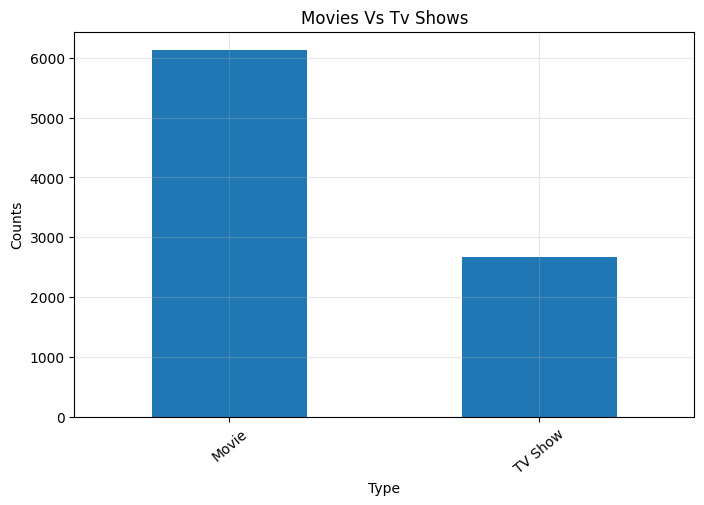

In [24]:
type_counts=df["type"].value_counts()
type_counts.plot(
    kind="bar",
    figsize=(8,5),
    title="Movies Vs Tv Shows"
)
plt.xlabel("Type")
plt.ylabel("Counts")
plt.xticks(rotation=40)
plt.grid(True,alpha=0.3)
plt.savefig(
    visuals_dir / "movies_vs_tv_shows.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


#### Step 5.2: Rating Plot

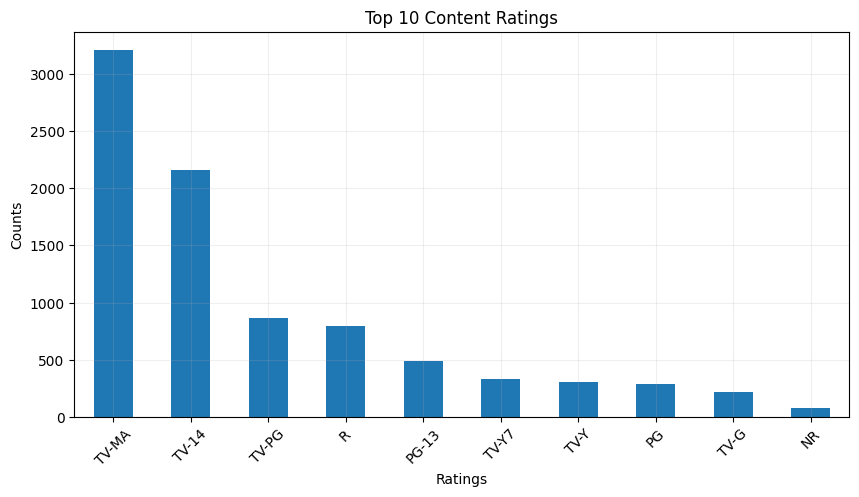

In [26]:
rating_counts=df["rating"].value_counts().head(10)
rating_counts.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Content Ratings"
)
plt.xlabel("Ratings")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.grid(True,alpha=0.2)
plt.savefig(
    visuals_dir/"Top 10 Content Ratings.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Step 5.3: Content Relase by Year

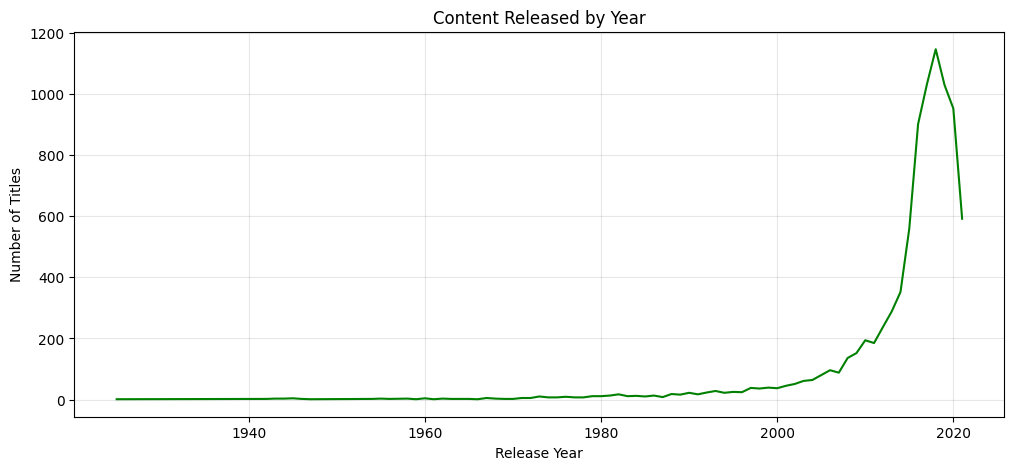

In [29]:
year_counts = df["release_year"].value_counts().sort_index()

year_counts.plot(
    kind="line",
    figsize=(12, 5),
    title="Content Released by Year",
    color="green"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True,alpha=0.3)
plt.savefig(
    visuals_dir/"Content Released by Year.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Step 5.4: Top 10 Genres

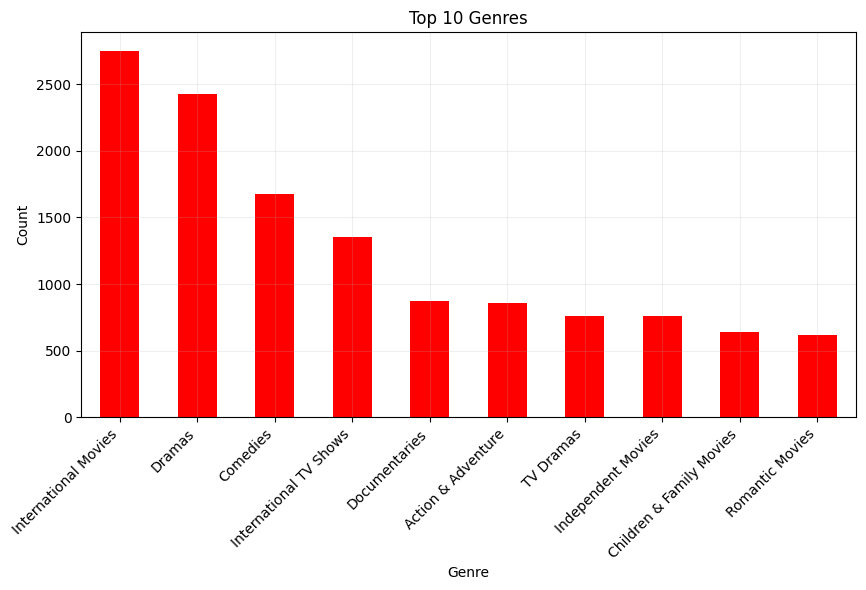

In [31]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

genre_counts = genres.value_counts().head(10)
genre_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Genres",
    color="red"
)

plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.grid(True,alpha=0.2)
plt.savefig(
    visuals_dir/"Top 10 Genres.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Step 6: Validation Check

In [32]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (8807, 12)

Missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Duplicate rows:
0


### Step 7: Saving the Cleaned df

In [33]:
output_path = "../Data/netflix_cleaned.csv"
df.to_csv(
    output_path,
    index=False
)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ../Data/netflix_cleaned.csv


In [35]:
df=pd.read_csv(output_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Data Cleaning Completed

The Netflix dataset has been successfully cleaned and validated.

### Final Steps Completed
- Handled missing values
- Corrected inconsistent values
- Fixed incorrect `rating` and `duration` entries
- Standardized unknown values as `Unknown`
- Checked duplicate records
- Performed basic exploratory data analysis (EDA)
- Saved the cleaned dataset as `netflix_cleaned.csv`

### Output
The cleaned dataset is now ready for the next stage:

**Data Cleaning → RAG Pipeline → Embeddings → FAISS Vector Store → Retrieval → LLM → Streamlit App**

📁 Cleaned dataset:
`../Data/netflix_cleaned.csv`
